# Yangın ve Duman Tespit Projesi
## Bilgisayar Mühendisliği - Görüntü İşleme Projesi

Bu projede:
- Veri Zenginleştirme (Augmentation)
- Yangın/Duman Özel İşlemler
- Gelişmiş Preprocessing
- Model Eğitimi (ResNet50)

teknikleri kullanılmaktadır.

In [15]:
# Gerekli Kütüphaneler
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder

In [16]:
# KLASÖR AYARLARI

base_dir = r"C:\Users\PC\Desktop\fire_project"
original_dataset = os.path.join(base_dir, "FIRE-SMOKE-DATASET")
aug_dataset = os.path.join(base_dir, "AugmentedDataset")

# Klasörleri oluştur
os.makedirs(os.path.join(aug_dataset, "train"), exist_ok=True)
os.makedirs(os.path.join(aug_dataset, "test"), exist_ok=True)

print("Klasörler hazır!")

Klasörler hazır!


## 1. Yangın Tespit Fonksiyonları

Yangın tespiti için HSV renk uzayı kullanılır. Yangın genellikle kırmızı-turuncu-sarı renk aralığındadır.

In [4]:

def detect_fire_hsv(img):
    """
    HSV renk uzayında yangın tespiti yapar.
    Yangın renkleri: Kırmızı, Turuncu, Sarı
    
    HSV Nedir?
    - H (Hue): Renk tonu (0-180)
    - S (Saturation): Doygunluk (0-255)
    - V (Value): Parlaklık (0-255)
    """
    # BGR'den HSV'ye çevir
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Yangın renk aralığı (kırmızı-turuncu-sarı)
    lower_fire = np.array([0, 50, 50])     # Alt sınır
    upper_fire = np.array([35, 255, 255])  # Üst sınır
    
    # Maske oluştur (yangın bölgelerini bul)
    mask = cv2.inRange(hsv, lower_fire, upper_fire)
    
    # Maskeyi görüntüye uygula
    result = cv2.bitwise_and(img, img, mask=mask)
    
    return result, mask


def get_fire_ratio(mask):
    """
    Görüntüdeki yangın oranını hesaplar.
    Ne kadar çok beyaz piksel varsa, o kadar çok yangın var demektir.
    """
    total_pixels = mask.shape[0] * mask.shape[1]
    fire_pixels = cv2.countNonZero(mask)
    ratio = fire_pixels / total_pixels
    return ratio


print("Yangın tespit fonksiyonları hazır!")

Yangın tespit fonksiyonları hazır!


## 2. Duman Tespit Fonksiyonları

Duman tespiti için YCbCr renk uzayı kullanılır. Duman genellikle gri tonlarında ve düşük satürasyonludur.

In [5]:
def detect_smoke_ycbcr(img):
    """
    YCbCr renk uzayında duman tespiti yapar.
    Duman özellikleri: Gri tonlar, düşük renk yoğunluğu
    
    YCbCr Nedir?
    - Y: Parlaklık
    - Cb: Mavi-sarı renk farkı
    - Cr: Kırmızı-yeşil renk farkı
    """
    # BGR'den YCbCr'ye çevir
    ycbcr = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
    
    # Y, Cb, Cr kanallarını ayır
    y, cr, cb = cv2.split(ycbcr)
    
    # Duman tespiti için koşullar:
    # - Parlaklık orta seviyede (80-220)
    # - Cb ve Cr değerleri birbirine yakın (gri tonlar)
    
    # Basit duman maskesi
    smoke_mask = np.zeros(y.shape, dtype=np.uint8)
    
    # Duman koşulları
    condition1 = (y > 80) & (y < 220)           # Orta parlaklık
    condition2 = np.abs(cb.astype(int) - cr.astype(int)) < 20  # Gri tonlar
    
    # Her iki koşul da sağlanıyorsa duman var
    smoke_mask[condition1 & condition2] = 255
    
    # Maskeyi görüntüye uygula
    result = cv2.bitwise_and(img, img, mask=smoke_mask)
    
    return result, smoke_mask


def get_smoke_ratio(mask):
    """
    Görüntüdeki duman oranını hesaplar.
    """
    total_pixels = mask.shape[0] * mask.shape[1]
    smoke_pixels = cv2.countNonZero(mask)
    ratio = smoke_pixels / total_pixels
    return ratio


print("Duman tespit fonksiyonları hazır!")

Duman tespit fonksiyonları hazır!


## 3. Texture (Doku) Analizi - LBP

LBP (Local Binary Pattern), görüntünün doku özelliklerini çıkarmak için kullanılır. Yangın ve dumanın kendine özgü doku yapısı vardır.

In [6]:
def calculate_lbp(img):
    """
    Basit LBP (Local Binary Pattern) hesaplar.
    
    LBP Nasıl Çalışır?
    - Her piksel için 8 komşusuna bakar
    - Merkez pikselden büyükse 1, küçükse 0 yazar
    - 8 bitlik bir sayı elde edilir (0-255)
    """
    # Gri tonlamaya çevir
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # LBP sonucu için boş görüntü
    lbp = np.zeros_like(gray)
    
    # Her piksel için LBP hesapla (kenarları atla)
    for i in range(1, gray.shape[0] - 1):
        for j in range(1, gray.shape[1] - 1):
            center = gray[i, j]
            
            # 8 komşuyu kontrol et (saat yönünde)
            code = 0
            code |= (gray[i-1, j-1] >= center) << 7  # Sol üst
            code |= (gray[i-1, j]   >= center) << 6  # Üst
            code |= (gray[i-1, j+1] >= center) << 5  # Sağ üst
            code |= (gray[i, j+1]   >= center) << 4  # Sağ
            code |= (gray[i+1, j+1] >= center) << 3  # Sağ alt
            code |= (gray[i+1, j]   >= center) << 2  # Alt
            code |= (gray[i+1, j-1] >= center) << 1  # Sol alt
            code |= (gray[i, j-1]   >= center) << 0  # Sol
            
            lbp[i, j] = code
    
    return lbp


def get_lbp_histogram(lbp_img):
    """
    LBP görüntüsünün histogramını hesaplar.
    Bu histogram doku özelliği olarak kullanılabilir.
    """
    hist, _ = np.histogram(lbp_img.ravel(), bins=256, range=(0, 256))
    # Normalize et
    hist = hist.astype(float) / hist.sum()
    return hist


print("LBP fonksiyonları hazır!")

LBP fonksiyonları hazır!


## 4. Gelişmiş Ön İşleme (Preprocessing)

Görüntü kalitesini artırmak için çeşitli ön işleme teknikleri uygulanır.

In [7]:
def denoise_image(img):
    """
    Görüntüdeki gürültüyü azaltır.
    Bilateral filtre hem gürültüyü azaltır hem kenarları korur.
    """
    # Bilateral filtre (daha hızlı alternatif)
    denoised = cv2.bilateralFilter(img, 9, 75, 75)
    return denoised


def enhance_contrast(img):
    """
    CLAHE ile kontrast iyileştirme yapar.
    CLAHE: Contrast Limited Adaptive Histogram Equalization
    """
    # LAB renk uzayına çevir
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    
    # CLAHE uygula
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    
    # Geri birleştir
    lab = cv2.merge((cl, a, b))
    result = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    
    return result


def sharpen_image(img):
    """
    Görüntüyü keskinleştirir.
    Kenarları daha belirgin hale getirir.
    """
    # Keskinleştirme kerneli
    kernel = np.array([[-1, -1, -1],
                       [-1,  9, -1],
                       [-1, -1, -1]])
    
    sharpened = cv2.filter2D(img, -1, kernel)
    return sharpened


def apply_morphology(mask):
    """
    Morfolojik işlemler uygular.
    - Opening: Küçük gürültüleri temizler
    - Closing: Küçük delikleri kapatır
    """
    kernel = np.ones((5, 5), np.uint8)
    
    # Opening (erosion + dilation)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    # Closing (dilation + erosion)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    
    return mask


def preprocess_image(img):
    """
    Tüm ön işleme adımlarını uygular.
    """
    # 1. Gürültü azaltma
    img = denoise_image(img)
    
    # 2. Kontrast iyileştirme
    img = enhance_contrast(img)
    
    # 3. Keskinleştirme
    img = sharpen_image(img)
    
    return img


print("Ön işleme fonksiyonları hazır!")

Ön işleme fonksiyonları hazır!


## 5. Veri Zenginleştirme (Augmentation)

Veri setini büyütmek için çeşitli dönüşümler uygulanır.

In [8]:
def random_flip(img):
    """Rastgele yatay çevirme"""
    if random.random() > 0.5:
        return cv2.flip(img, 1)
    return img


def random_rotation(img):
    """Rastgele döndürme (90, 180, 270 derece)"""
    angle = random.choice([0, 90, 180, 270])
    
    if angle == 90:
        return cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    elif angle == 180:
        return cv2.rotate(img, cv2.ROTATE_180)
    elif angle == 270:
        return cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
    return img


def random_brightness(img):
    """Rastgele parlaklık değişimi"""
    # -30 ile +30 arasında rastgele değer
    value = random.randint(-30, 30)
    
    # HSV'ye çevir
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    
    # V kanalını değiştir
    v = np.clip(v.astype(int) + value, 0, 255).astype(np.uint8)
    
    # Geri birleştir
    hsv = cv2.merge((h, s, v))
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)


def add_gaussian_noise(img):
    """Gaussian gürültü ekle"""
    noise = np.random.normal(0, 10, img.shape).astype(np.uint8)
    noisy = cv2.add(img, noise)
    return noisy


def augment_image(img):
    """
    Tek bir görüntüye rastgele augmentation uygular.
    """
    aug = img.copy()
    
    # Rastgele augmentation'ları uygula
    aug = random_flip(aug)
    aug = random_rotation(aug)
    
    # %50 ihtimalle parlaklık değiştir
    if random.random() > 0.5:
        aug = random_brightness(aug)
    
    # %30 ihtimalle gürültü ekle
    if random.random() > 0.7:
        aug = add_gaussian_noise(aug)
    
    return aug


print("Veri zenginleştirme fonksiyonları hazır!")

Veri zenginleştirme fonksiyonları hazır!


## 6. Augmented Dataset Oluşturma

Tüm görüntüleri işleyip yeni dataset'i oluşturur.

In [9]:
############################################
# AUGMENTED DATASET OLUŞTURMA
############################################

def create_augmented_dataset():
    """
    Orijinal dataset'i işleyip augmented versiyonunu oluşturur.
    """
    print("Augmented dataset oluşturuluyor...")
    print("Bu işlem biraz zaman alabilir...")
    
    for folder in ["train", "test"]:
        input_path = os.path.join(original_dataset, folder)
        output_path = os.path.join(aug_dataset, folder)
        
        # Her sınıf için (fire, smoke, neutral)
        for class_name in os.listdir(input_path):
            class_in = os.path.join(input_path, class_name)
            class_out = os.path.join(output_path, class_name)
            
            os.makedirs(class_out, exist_ok=True)
            
            img_list = os.listdir(class_in)
            total = len(img_list)
            
            print(f"\n{folder}/{class_name}: {total} görüntü işleniyor...")
            
            for idx, img_name in enumerate(img_list):
                img_path = os.path.join(class_in, img_name)
                img = cv2.imread(img_path)
                
                if img is None:
                    continue
                
                # 1) Ön işleme uygula ve kaydet
                processed = preprocess_image(img)
                cv2.imwrite(os.path.join(class_out, img_name), processed)
                
                # 2) 2 tane augmented versiyon oluştur
                for i in range(2):
                    aug = augment_image(processed)
                    new_name = f"{img_name.split('.')[0]}_aug{i}.jpg"
                    cv2.imwrite(os.path.join(class_out, new_name), aug)
                
                # İlerleme göster
                if (idx + 1) % 100 == 0:
                    print(f"  {idx + 1}/{total} tamamlandı...")
    
    print("\n✓ Augmented Dataset hazır!")


# Dataset'i oluştur
create_augmented_dataset()

Augmented dataset oluşturuluyor...
Bu işlem biraz zaman alabilir...

train/Fire: 900 görüntü işleniyor...
  100/900 tamamlandı...
  200/900 tamamlandı...
  300/900 tamamlandı...
  400/900 tamamlandı...
  500/900 tamamlandı...
  600/900 tamamlandı...
  700/900 tamamlandı...
  800/900 tamamlandı...
  900/900 tamamlandı...

train/Neutral: 900 görüntü işleniyor...
  100/900 tamamlandı...
  200/900 tamamlandı...
  300/900 tamamlandı...
  400/900 tamamlandı...
  500/900 tamamlandı...
  600/900 tamamlandı...
  700/900 tamamlandı...
  800/900 tamamlandı...
  900/900 tamamlandı...

train/Smoke: 900 görüntü işleniyor...
  100/900 tamamlandı...
  200/900 tamamlandı...
  300/900 tamamlandı...
  400/900 tamamlandı...
  500/900 tamamlandı...
  600/900 tamamlandı...
  700/900 tamamlandı...
  800/900 tamamlandı...
  900/900 tamamlandı...

test/Fire: 100 görüntü işleniyor...
  100/100 tamamlandı...

test/Neutral: 100 görüntü işleniyor...
  100/100 tamamlandı...

test/Smoke: 100 görüntü işleniyor...
  1

## 7. Dataset ve DataLoader

PyTorch için veri yükleme işlemleri.

In [10]:
# Görüntü dönüşümleri
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Dataset'leri yükle
train_dataset = ImageFolder(os.path.join(aug_dataset, "train"), transform=train_transform)
test_dataset = ImageFolder(os.path.join(aug_dataset, "test"), transform=test_transform)

# DataLoader'ları oluştur
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Sınıf bilgilerini göster
print("Sınıflar:", train_dataset.classes)
print(f"Eğitim seti: {len(train_dataset)} görüntü")
print(f"Test seti: {len(test_dataset)} görüntü")

Sınıflar: ['Fire', 'Neutral', 'Smoke']
Eğitim seti: 8100 görüntü
Test seti: 900 görüntü


## 8. Model - ResNet50

Transfer Learning ile ResNet50 modeli kullanılır.

In [11]:
# GPU varsa kullan, yoksa CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

# Önceden eğitilmiş ResNet50 modelini yükle 
from torchvision.models import resnet50, ResNet50_Weights

model = resnet50(weights=ResNet50_Weights.DEFAULT)

# Son katmanı sınıf sayısına göre değiştir
num_classes = len(train_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Modeli cihaza taşı
model = model.to(device)

# Loss fonksiyonu ve optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print(f"Model hazır! Sınıf sayısı: {num_classes}")

Kullanılan cihaz: cpu
Model hazır! Sınıf sayısı: 3


## 9. Model Eğitimi

In [12]:

def train_model(epochs=10):
    
    print("Eğitim başlıyor...\n")
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            
            # Gradyanları sıfırla
            optimizer.zero_grad()
            
            # İleri hesaplama
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            
            # Geri yayılım
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
            # Doğruluk hesapla
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        # Epoch sonuçları
        avg_loss = total_loss / len(train_loader)
        accuracy = 100 * correct / total
        
        print(f"Epoch [{epoch+1}/{epochs}]  Loss: {avg_loss:.4f}  Accuracy: {accuracy:.2f}%")
    
    # Modeli kaydet
    torch.save(model.state_dict(), "fire_smoke_model.pth")
    print("\n✓ Model kaydedildi: fire_smoke_model.pth")


# Eğitimi başlat
train_model(epochs=10)

Eğitim başlıyor...

Epoch [1/10]  Loss: 0.2608  Accuracy: 91.63%
Epoch [2/10]  Loss: 0.0862  Accuracy: 97.00%
Epoch [3/10]  Loss: 0.0521  Accuracy: 98.47%
Epoch [4/10]  Loss: 0.0551  Accuracy: 98.20%
Epoch [5/10]  Loss: 0.0308  Accuracy: 99.04%
Epoch [6/10]  Loss: 0.0317  Accuracy: 99.14%
Epoch [7/10]  Loss: 0.0262  Accuracy: 99.22%
Epoch [8/10]  Loss: 0.0219  Accuracy: 99.36%
Epoch [9/10]  Loss: 0.0264  Accuracy: 99.32%
Epoch [10/10]  Loss: 0.0192  Accuracy: 99.44%

✓ Model kaydedildi: fire_smoke_model.pth


## 10. Model Test

In [12]:
def test_model():
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    print(f"Test Doğruluğu: {accuracy:.2f}%")
    return accuracy


# Test et
test_model()

Test Doğruluğu: 26.67%


26.666666666666668

## 11. Tek Görsel Tahmin

Eğitilmiş modelle tek bir görsel için tahmin yapar.

In [13]:
def predict_image(image_path):
    # Sinif isimleri
    class_names = train_dataset.classes  # ['fire', 'neutral', 'smoke']
    
    # Gorseli yukle
    img = Image.open(image_path).convert('RGB')
    
    # Donusum uygula
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    # Tahmin yap
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
    
    # Sonuc
    result = class_names[predicted.item()]
    conf = confidence.item() * 100
    
    print(f"\nTahmin: {result.upper()}")
    print(f"Guven: {conf:.2f}%")
    
    # Tum siniflarin olasiliklari
    print("\nTum olasilikar:")
    for i, class_name in enumerate(class_names):
        prob = probabilities[0][i].item() * 100
        print(f"  {class_name}: {prob:.2f}%")
    
    return result, conf


# Gorseli test et
predict_image(r"C:\Users\PC\Desktop\fire_project\deneme.jpg")
predict_image(r"C:\Users\PC\Desktop\fire_project\test2.jpg")
predict_image(r"C:\Users\PC\Desktop\fire_project\test3.jpg")
predict_image(r"C:\Users\PC\Desktop\fire_project\test4.jpg")


Tahmin: SMOKE
Guven: 34.92%

Tum olasilikar:
  Fire: 34.65%
  Neutral: 30.43%
  Smoke: 34.92%

Tahmin: FIRE
Guven: 39.48%

Tum olasilikar:
  Fire: 39.48%
  Neutral: 24.58%
  Smoke: 35.94%

Tahmin: FIRE
Guven: 36.45%

Tum olasilikar:
  Fire: 36.45%
  Neutral: 27.77%
  Smoke: 35.78%

Tahmin: NEUTRAL
Guven: 35.30%

Tum olasilikar:
  Fire: 33.80%
  Neutral: 35.30%
  Smoke: 30.90%


('Neutral', 35.301974415779114)

## 12. Yangın/Duman Analiz Fonksiyonu

Bir görseli analiz edip detaylı rapor verir.

In [14]:
def analyze_image(image_path):
    """
    Görseli analiz eder ve detaylı rapor verir.
    - HSV yangın analizi
    - YCbCr duman analizi
    - Model tahmini
    """
    print("="*50)
    print("GÖRÜNTÜ ANALİZ RAPORU")
    print("="*50)
    
    # Görseli oku
    img = cv2.imread(image_path)
    
    if img is None:
        print("Hata: Görsel yüklenemedi!")
        return
    
    # 1. Yangın analizi (HSV)
    _, fire_mask = detect_fire_hsv(img)
    fire_ratio = get_fire_ratio(fire_mask) * 100
    print(f"\n1. HSV Yangın Analizi:")
    print(f"   Yangın piksel oranı: {fire_ratio:.2f}%")
    
    # 2. Duman analizi (YCbCr)
    _, smoke_mask = detect_smoke_ycbcr(img)
    smoke_ratio = get_smoke_ratio(smoke_mask) * 100
    print(f"\n2. YCbCr Duman Analizi:")
    print(f"   Duman piksel oranı: {smoke_ratio:.2f}%")
    
    # 3. Model tahmini
    print(f"\n3. Model Tahmini:")
    result, conf = predict_image(image_path)
    
    # 4. Sonuç değerlendirmesi
    print("\n" + "="*50)
    print("SONUÇ:")
    
    if result == "fire":
        print("⚠️  YANGIN TESPİT EDİLDİ!")
    elif result == "smoke":
        print("⚠️  DUMAN TESPİT EDİLDİ!")
    else:
        print("✓ Normal görüntü, tehlike yok.")
    
    print("="*50)

analyze_image(r"C:\Users\PC\Desktop\fire_project\deneme.jpg")
analyze_image(r"C:\Users\PC\Desktop\fire_project\test2.jpg")
analyze_image(r"C:\Users\PC\Desktop\fire_project\test3.jpg")
analyze_image(r"C:\Users\PC\Desktop\fire_project\test4.jpg")


GÖRÜNTÜ ANALİZ RAPORU

1. HSV Yangın Analizi:
   Yangın piksel oranı: 56.15%

2. YCbCr Duman Analizi:
   Duman piksel oranı: 6.31%

3. Model Tahmini:

Tahmin: SMOKE
Guven: 34.92%

Tum olasilikar:
  Fire: 34.65%
  Neutral: 30.43%
  Smoke: 34.92%

SONUÇ:
✓ Normal görüntü, tehlike yok.
GÖRÜNTÜ ANALİZ RAPORU

1. HSV Yangın Analizi:
   Yangın piksel oranı: 39.86%

2. YCbCr Duman Analizi:
   Duman piksel oranı: 23.31%

3. Model Tahmini:

Tahmin: FIRE
Guven: 39.48%

Tum olasilikar:
  Fire: 39.48%
  Neutral: 24.58%
  Smoke: 35.94%

SONUÇ:
✓ Normal görüntü, tehlike yok.
GÖRÜNTÜ ANALİZ RAPORU

1. HSV Yangın Analizi:
   Yangın piksel oranı: 24.90%

2. YCbCr Duman Analizi:
   Duman piksel oranı: 22.91%

3. Model Tahmini:

Tahmin: FIRE
Guven: 36.45%

Tum olasilikar:
  Fire: 36.45%
  Neutral: 27.77%
  Smoke: 35.78%

SONUÇ:
✓ Normal görüntü, tehlike yok.
GÖRÜNTÜ ANALİZ RAPORU

1. HSV Yangın Analizi:
   Yangın piksel oranı: 14.22%

2. YCbCr Duman Analizi:
   Duman piksel oranı: 35.86%

3. Model Tahmin

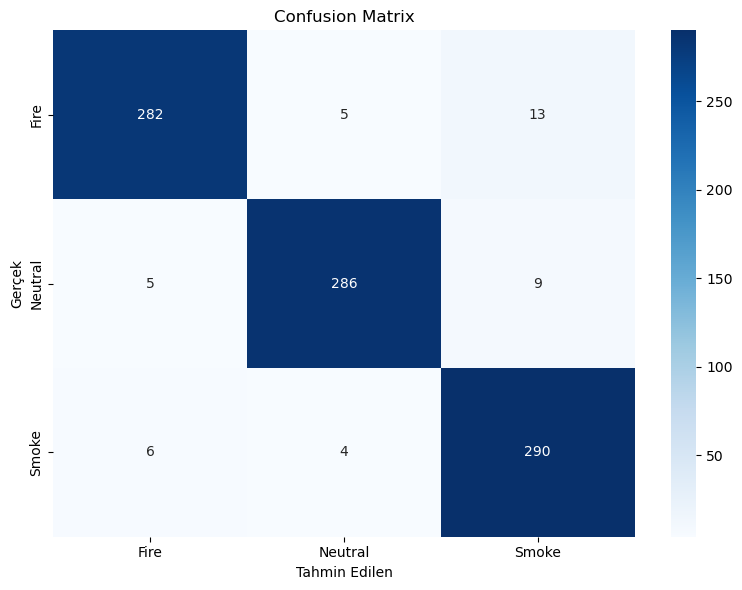


SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

        Fire       0.96      0.94      0.95       300
     Neutral       0.97      0.95      0.96       300
       Smoke       0.93      0.97      0.95       300

    accuracy                           0.95       900
   macro avg       0.95      0.95      0.95       900
weighted avg       0.95      0.95      0.95       900

ÖZET
Toplam Test Görüntüsü: 900
Doğru Tahmin: 858
Yanlış Tahmin: 42
Genel Doğruluk: %95.33


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def create_confusion_matrix():
    """
    Test seti üzerinde confusion matrix oluşturur.
    """
    model.eval()
    
    all_predictions = []  # Tüm tahminler
    all_labels = []       # Tüm gerçek etiketler
    
    # Test setini değerlendir
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            
            # Listeye ekle
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Numpy array'e çevir
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    
    # Sınıf isimleri
    class_names = train_dataset.classes  # ['fire', 'neutral', 'smoke']
    
    # Confusion Matrix hesapla
    cm = confusion_matrix(all_labels, all_predictions)
    
    # Görselleştir
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Tahmin Edilen')
    plt.ylabel('Gerçek')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150)
    plt.show()
    
    # Classification Report yazdır
    print("\n" + "="*50)
    print("SINIFLANDIRMA RAPORU")
    print("="*50)
    print(classification_report(all_labels, all_predictions, 
                                target_names=class_names))
    
    # Özet bilgiler
    print("="*50)
    print("ÖZET")
    print("="*50)
    
    total = len(all_labels)
    correct = (all_predictions == all_labels).sum()
    accuracy = 100 * correct / total
    
    print(f"Toplam Test Görüntüsü: {total}")
    print(f"Doğru Tahmin: {correct}")
    print(f"Yanlış Tahmin: {total - correct}")
    print(f"Genel Doğruluk: %{accuracy:.2f}")
    
    return cm


# Çalıştır
cm = create_confusion_matrix()
